In [8]:
import yfinance as yf
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [9]:
stocks = ["AAPL","MSFT","GOOGL","AMZN"]

In [10]:
data = yf.download(stocks, start = "2022-01-01" , end = "2025-01-01")

[*********************100%***********************]  4 of 4 completed


In [11]:
close = data["Close"]
returns = close.pct_change().dropna()

In [12]:
stocks = ['AAPL','MSFT','GOOGL','AMZN']
data = yf.download(stocks, start = "2022-01-01", end="2025-01-01")
close = data['Close']
returns = close.pct_change().dropna()

print(close.head())
print(returns.head())

[*********************100%***********************]  4 of 4 completed

Ticker            AAPL        AMZN       GOOGL        MSFT
Date                                                      
2022-01-03  178.103668  170.404495  143.802994  323.160767
2022-01-04  175.843246  167.522003  143.215836  317.619507
2022-01-05  171.165833  164.356995  136.645630  305.426727
2022-01-06  168.308517  163.253998  136.618362  303.013336
2022-01-07  168.474854  162.554001  135.893829  303.167755
Ticker          AAPL      AMZN     GOOGL      MSFT
Date                                              
2022-01-04 -0.012692 -0.016916 -0.004083 -0.017147
2022-01-05 -0.026600 -0.018893 -0.045876 -0.038388
2022-01-06 -0.016693 -0.006711 -0.000200 -0.007902
2022-01-07  0.000988 -0.004288 -0.005303  0.000510
2022-01-10  0.000116 -0.006570  0.012061  0.000732


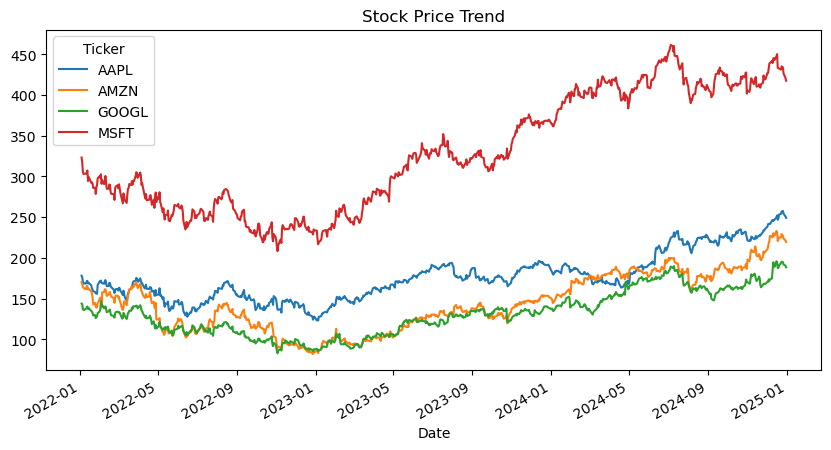

In [16]:
import matplotlib.pyplot as plt
close.plot(figsize=(10,5))
plt.title("Stock Price Trend")
plt.show()

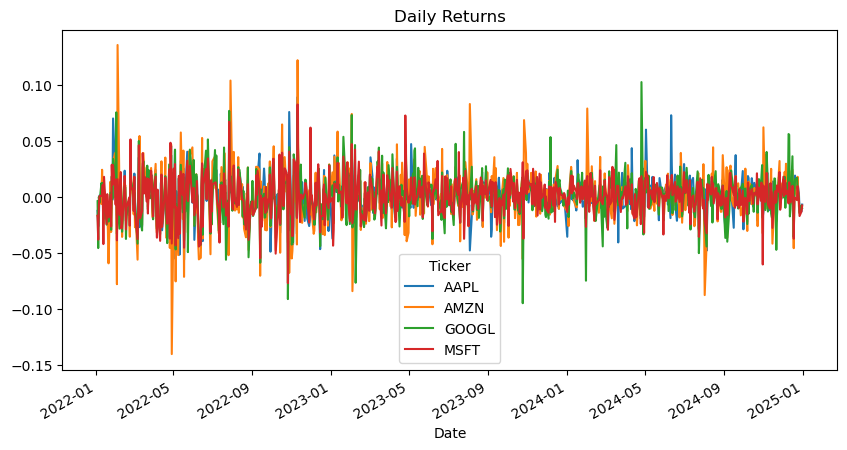

In [19]:
returns = close.pct_change()
returns.plot(figsize=(10,5))
plt.title("Daily Returns")
plt.show()

In [22]:
returns.describe()

Ticker,AAPL,AMZN,GOOGL,MSFT
count,752.000000,752.000000,752.000000,752.000000
mean,0.000591,0.000627,0.000572,0.000491
std,0.017067,0.024147,0.020627,0.017372
min,-0.058680,-0.140494,-0.095094,-0.077156
25%,-0.008437,-0.012626,-0.011606,-0.008516
50%,0.001117,0.000331,0.001098,0.000789
75%,0.009751,0.014102,0.011492,0.010602
max,0.088975,0.135359,0.102244,0.082268


In [23]:
returns.std()

Ticker
AAPL     0.017067
AMZN     0.024147
GOOGL    0.020627
MSFT     0.017372
dtype: float64

In [24]:
returns.mean()

Ticker
AAPL     0.000591
AMZN     0.000627
GOOGL    0.000572
MSFT     0.000491
dtype: float64

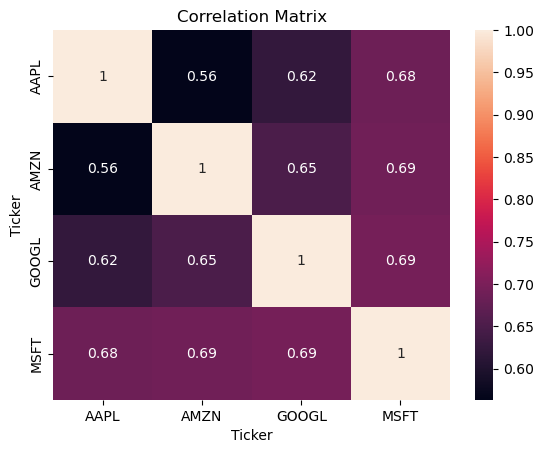

In [25]:
corr = returns.corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

In [27]:
weights = [0.25,0.25,0.25,0.25]

In [28]:
portfolio_return = np.sum(returns.mean()*weights)
print(portfolio_return)

0.0005704066336339447


In [29]:
portfolio_std = np.sqrt(
    np.dot(weights,np.dot(returns.cov(),weights))
)
print(portfolio_std)

0.01701716060921925


In [31]:
risk_free_rate = 0.07

sharpe = (portfolio_return*252 - risk_free_rate)/(portfolio_std*np.sqrt(252))
print(sharpe)

0.2729796809759225


In [34]:
num_ports = 5000
all_weights = []
ret_arr = []
vol_arr = []
sharpe_arr = []

for _ in range(num_ports):
    weights = np.random.random(4)
    weights = weights /np.sum(weights)

    all_weights.append(weights)

    ret = np.sum(returns.mean()*weights)*252
    vol = np.sqrt(np.dot(weights,np.dot(returns.cov()*252, weight)))

    sharpe = (ret-0.07)/vol

    ret_arr.append(ret)
    vol_arr.append(vol)
    sharpe_arr.append(sharpe)
    

In [39]:
max_sharpe = max(sharpe_arr)

index = sharpe_arr.index(max_sharpe)

best_weights = all_weights[index]

print("Best Sharpe Ratio:" , max_sharpe)
print("Best weights:" , best_weights)

Best Sharpe Ratio: 0.31509589532679466
Best weights: [0.83766128 0.12188102 0.02683512 0.01362258]


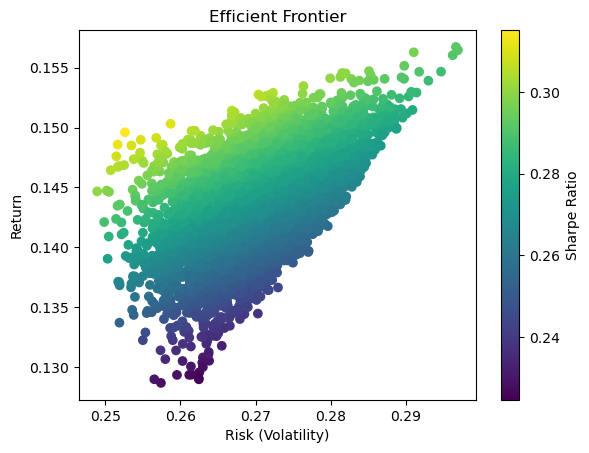

In [40]:
plt.scatter(vol_arr,ret_arr,c=sharpe_arr)
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Risk (Volatility)')
plt.ylabel('Return')
plt.title('Efficient Frontier')
plt.show()

In [41]:
close.to_csv("stock_prices.csv")
returns.to_csv("returns.csv")